In [1]:

import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import wandb

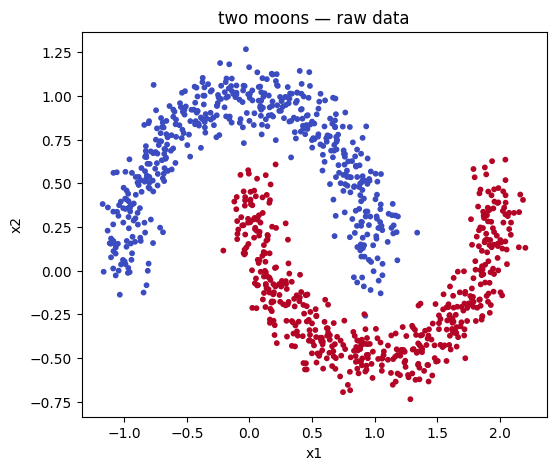

In [2]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=0) # make a data distribution! each (x1,x2) maps to some probability y

# visualize!
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='coolwarm')
plt.title("two moons — raw data")
plt.xlabel("x1"); plt.ylabel("x2")
plt.savefig("raw_data.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# cool now we want the mlp to be able to distinguish between these classes!

# first we must make said MLP

class MLP(nn.Module):
    def __init__(self, hidden=67):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), # first layer preactivations: 2 neurons
            nn.ReLU(),
            nn.Linear(hidden, hidden), # two 32-layer neurons because funsies
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )
    
    def forward(self, x):
        return self.net(x)


# wow fire!
model = MLP()

In [ ]:
# how are we defining loss for this thing??

# for binary classification we want to argmax the probability of label y matching input [x1, x2]T
# we can model this probability as Bernoulli because it simply is or isn't, so just one parameter p is needed
# this ALSO means our output logit better be in [0,1] so it can represent a probability of being a particular label
# so we sigmoid it!
# so what we want is to estimate the parameter p for any given input x ~ sigmoid(model(x)) --> i'll refer to sigmoid(model(x)) as simply f
# we can represent this probability with a neat little expression: (1-f)**(1-y) * (f)**y --> this ONLY works because we're guaranteed y is either one class or the other ("binary" :O)

# THIS IS EXPR FOR ONE TRAINING EXAMPLE!!
# to argmax the "aggregated" probability of a correct label y given input x, we want to MULTIPLY the probabilities from each training example together
# and now we just argmax this expression over the parameters of the model!
# ...which is equivalent to argminning the negative log of this expression

# which also
